In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
import my_functions

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [5]:
import sklearn.cluster

In [6]:
dir(sklearn.cluster)

['AffinityPropagation',
 'AgglomerativeClustering',
 'Birch',
 'BisectingKMeans',
 'DBSCAN',
 'FeatureAgglomeration',
 'HDBSCAN',
 'KMeans',
 'MeanShift',
 'MiniBatchKMeans',
 'OPTICS',
 'SpectralBiclustering',
 'SpectralClustering',
 'SpectralCoclustering',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_affinity_propagation',
 '_agglomerative',
 '_bicluster',
 '_birch',
 '_bisect_k_means',
 '_dbscan',
 '_dbscan_inner',
 '_feature_agglomeration',
 '_hdbscan',
 '_hierarchical_fast',
 '_k_means_common',
 '_k_means_elkan',
 '_k_means_lloyd',
 '_k_means_minibatch',
 '_kmeans',
 '_mean_shift',
 '_optics',
 '_spectral',
 'affinity_propagation',
 'cluster_optics_dbscan',
 'cluster_optics_xi',
 'compute_optics_graph',
 'dbscan',
 'estimate_bandwidth',
 'get_bin_seeds',
 'k_means',
 'kmeans_plusplus',
 'linkage_tree',
 'mean_shift',
 'spectral_clustering',
 'ward_tree']

In [8]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(n_clusters=8, *, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')
 |  
 |  K-Means clustering.
 |  
 |  Read more in the :ref:`User Guide <k_means>`.
 |  
 |  Parameters
 |  ----------
 |  
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |  
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |  
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |  
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to t

In [9]:
random_seed = 42
centers = [(0,0), (5,5), (0,5)]
cluster_std = 1.5
n_features = 2
n_samples = 2100

In [14]:
X, y = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=centers,
    cluster_std=cluster_std,
    random_state=random_seed,
)



In [15]:
X,y = pd.DataFrame(X, columns=['varA', 'varB']), pd.Series(y)

In [16]:
data1 = X[y==0]
data2 = X[y==1].sample(400, random_state=0)
data3 = X[y==2].sample(100, random_state=0)

In [18]:
X = pd.concat([data1, data2, data3], axis=0)

In [19]:
X.shape, y.shape

((1200, 2), (2100,))

In [22]:
y = y.loc[X.index]
y.shape, y.value_counts()

((1200,),
 0    700
 1    400
 2    100
 Name: count, dtype: int64)

In [23]:
?X.reset_index

Signature:
X.reset_index(
    level: 'IndexLabel | None' = None,
    *,
    drop: 'bool' = False,
    inplace: 'bool' = False,
    col_level: 'Hashable' = 0,
    col_fill: 'Hashable' = '',
    allow_duplicates: 'bool | lib.NoDefault' = <no_default>,
    names: 'Hashable | Sequence[Hashable] | None' = None,
) -> 'DataFrame | None'
Docstring:
Reset the index, or a level of it.

Reset the index of the DataFrame, and use the default one instead.
If the DataFrame has a MultiIndex, this method can remove one or more
levels.

Parameters
----------
level : int, str, tuple, or list, default None
    Only remove the given levels from the index. Removes all levels by
    default.
drop : bool, default False
    Do not try to insert index into dataframe columns. This resets
    the index to the default integer index.
inplace : bool, default False
    Whether to modify the DataFrame rather than creating a new one.
col_level : int or str, default 0
    If the columns have multiple levels, determines 

In [24]:
help(X.reset_index)

Help on method reset_index in module pandas.core.frame:

reset_index(level: 'IndexLabel | None' = None, *, drop: 'bool' = False, inplace: 'bool' = False, col_level: 'Hashable' = 0, col_fill: 'Hashable' = '', allow_duplicates: 'bool | lib.NoDefault' = <no_default>, names: 'Hashable | Sequence[Hashable] | None' = None) -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Reset the index, or a level of it.
    
    Reset the index of the DataFrame, and use the default one instead.
    If the DataFrame has a MultiIndex, this method can remove one or more
    levels.
    
    Parameters
    ----------
    level : int, str, tuple, or list, default None
        Only remove the given levels from the index. Removes all levels by
        default.
    drop : bool, default False
        Do not try to insert index into dataframe columns. This resets
        the index to the default integer index.
    inplace : bool, default False
        Whether to modify the DataFrame rather th

In [25]:
X.index

Index([   2,    3,    4,    5,    6,    8,   17,   22,   25,   27,
       ...
        467, 2087, 1105,  983,  110,  700,  147, 1402, 1302,  697],
      dtype='int64', length=1200)

In [26]:
X.reset_index(drop=True).index

RangeIndex(start=0, stop=1200, step=1)

In [27]:
X.head(10)

,varA,varB
2,-2.8062,-0.5273
3,0.2698,2.0880
4,0.9579,-2.4923
5,-0.1232,1.6759
6,-4.8619,-1.5366
8,-2.9906,0.5611
17,-0.1429,0.4185
22,0.6900,-1.0166
25,-1.5977,-0.4578
27,-0.3662,1.4461


In [ ]:
#Need to use the drop parameter, otherwise the old index will be added to the dataframe as a different column

X.reset_index(drop=True).head(10)

,varA,varB
0,-2.8062,-0.5273
1,0.2698,2.0880
2,0.9579,-2.4923
3,-0.1232,1.6759
4,-4.8619,-1.5366
5,-2.9906,0.5611
6,-0.1429,0.4185
7,0.6900,-1.0166
8,-1.5977,-0.4578
9,-0.3662,1.4461


In [29]:
help(X.reset_index)

Help on method reset_index in module pandas.core.frame:

reset_index(level: 'IndexLabel | None' = None, *, drop: 'bool' = False, inplace: 'bool' = False, col_level: 'Hashable' = 0, col_fill: 'Hashable' = '', allow_duplicates: 'bool | lib.NoDefault' = <no_default>, names: 'Hashable | Sequence[Hashable] | None' = None) -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Reset the index, or a level of it.
    
    Reset the index of the DataFrame, and use the default one instead.
    If the DataFrame has a MultiIndex, this method can remove one or more
    levels.
    
    Parameters
    ----------
    level : int, str, tuple, or list, default None
        Only remove the given levels from the index. Removes all levels by
        default.
    drop : bool, default False
        Do not try to insert index into dataframe columns. This resets
        the index to the default integer index.
    inplace : bool, default False
        Whether to modify the DataFrame rather th

In [32]:
X.reset_index(drop=True,  inplace=True)
y.reset_index(drop=True, inplace=True)

In [31]:
(X.index == y.index).sum()

np.int64(1200)

In [33]:
help(np.random.binomial)

Help on method binomial in module numpy.random:

binomial(n, p, size=None) method of numpy.random.mtrand.RandomState instance
    binomial(n, p, size=None)
    
    Draw samples from a binomial distribution.
    
    Samples are drawn from a binomial distribution with specified
    parameters, n trials and p probability of success where
    n an integer >= 0 and p is in the interval [0,1]. (n may be
    input as a float, but it is truncated to an integer in use)
    
    .. note::
        New code should use the `~numpy.random.Generator.binomial`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.
    
    Parameters
    ----------
    n : int or array_like of ints
        Parameter of the distribution, >= 0. Floats are also accepted,
        but they will be truncated to integers.
    p : float or array_like of floats
        Parameter of the distribution, >= 0 and <=1.
    size : int or tuple of ints, optional
        Outp

In [35]:
?np.random.binomial

Signature: np.random.binomial(n, p, size=None)
Docstring:
binomial(n, p, size=None)

Draw samples from a binomial distribution.

Samples are drawn from a binomial distribution with specified
parameters, n trials and p probability of success where
n an integer >= 0 and p is in the interval [0,1]. (n may be
input as a float, but it is truncated to an integer in use)

.. note::
    New code should use the `~numpy.random.Generator.binomial`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
n : int or array_like of ints
    Parameter of the distribution, >= 0. Floats are also accepted,
    but they will be truncated to integers.
p : float or array_like of floats
    Parameter of the distribution, >= 0 and <=1.
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  If size is ``None`` (default),
    a single value is returned 

In [ ]:
#A case where we flip coins 10 times where the probability of success,t hat is the probability of obtaining the desired output, for example head is 0.5
#This would be an example whee we are assuming the coind fair
#We then do 10-coin filpping 1000 times and the result below is the number of times out of 10 we obtain our desired output
np.random.binomial(10, 0.5, 1000)

array([3, 4, 7, 2, 3, 4, 8, 6, 4, 5, 7, 6, 4, 5, 6, 2, 3, 5, 8, 3, 3, 2,
       6, 6, 8, 5, 7, 5, 5, 8, 5, 6, 5, 6, 4, 8, 4, 4, 4, 4, 6, 7, 9, 6,
       3, 8, 7, 3, 5, 7, 4, 5, 5, 5, 6, 6, 3, 4, 8, 4, 5, 3, 4, 7, 3, 7,
       8, 6, 3, 5, 6, 7, 7, 4, 6, 5, 8, 4, 4, 6, 4, 4, 4, 6, 8, 6, 5, 5,
       5, 6, 4, 6, 5, 5, 6, 7, 5, 4, 6, 5, 5, 5, 2, 4, 4, 5, 6, 4, 6, 3,
       6, 6, 3, 3, 6, 6, 5, 6, 3, 8, 5, 6, 6, 3, 6, 2, 6, 7, 6, 6, 7, 4,
       6, 5, 3, 2, 5, 2, 6, 3, 5, 6, 4, 6, 6, 5, 5, 3, 8, 5, 3, 3, 7, 4,
       4, 3, 5, 3, 6, 2, 6, 5, 5, 5, 2, 5, 2, 7, 6, 4, 5, 5, 7, 6, 5, 4,
       5, 7, 6, 7, 2, 4, 4, 3, 5, 3, 5, 8, 4, 5, 6, 5, 5, 6, 6, 5, 6, 4,
       6, 6, 7, 5, 3, 3, 4, 7, 6, 3, 4, 4, 4, 4, 4, 5, 5, 4, 4, 7, 5, 2,
       7, 6, 4, 5, 3, 5, 9, 4, 4, 7, 3, 4, 5, 5, 5, 8, 5, 3, 4, 4, 5, 5,
       5, 4, 6, 5, 5, 3, 5, 5, 7, 6, 6, 5, 6, 9, 6, 5, 2, 1, 6, 5, 2, 1,
       7, 6, 8, 3, 5, 6, 4, 3, 2, 2, 5, 6, 5, 5, 5, 8, 3, 7, 7, 5, 4, 4,
       7, 3, 2, 6, 6, 6, 7, 6, 5, 8, 8, 5, 6, 7, 4,

In [45]:
y = pd.concat([pd.Series(np.random.binomial(1,0.3,700)),
pd.Series(np.random.binomial(1,0.2,400)),
pd.Series(np.random.binomial(1,0.1,100))], axis=0)

In [46]:
y.index

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       ...
       90, 91, 92, 93, 94, 95, 96, 97, 98, 99],
      dtype='int64', length=1200)

In [47]:
y.reset_index(drop=True).index

RangeIndex(start=0, stop=1200, step=1)

In [48]:
y = y.reset_index(drop=True)

In [49]:
X.shape, y.shape

((1200, 2), (1200,))

In [50]:
y.value_counts()

0    888
1    312
Name: count, dtype: int64

In [51]:
X.columns

Index(['varA', 'varB'], dtype='object')

In [52]:
X.shape, y.shape

((1200, 2), (1200,))

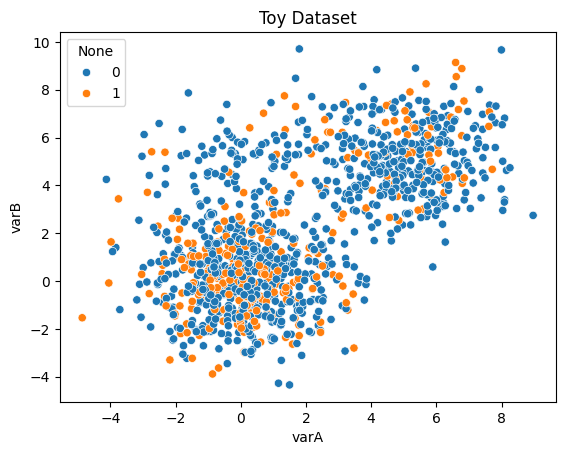

In [54]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y
)
plt.title('Toy Dataset')
plt.show()

# K Means SMOTE

In [56]:
import imblearn.over_sampling

In [57]:
for item in (dir(imblearn.over_sampling)):
    if 'kmeans' in item.lower():
        print(item)

KMeansSMOTE


In [58]:
from imblearn.over_sampling import KMeansSMOTE

In [59]:
help(KMeansSMOTE)

Help on class KMeansSMOTE in module imblearn.over_sampling._smote.cluster:

class KMeansSMOTE(imblearn.over_sampling._smote.base.BaseSMOTE)
 |  KMeansSMOTE(*, sampling_strategy='auto', random_state=None, k_neighbors=2, n_jobs=None, kmeans_estimator=None, cluster_balance_threshold='auto', density_exponent='auto')
 |  
 |  Apply a KMeans clustering before to over-sample using SMOTE.
 |  
 |  This is an implementation of the algorithm described in [1]_.
 |  
 |  Read more in the :ref:`User Guide <smote_adasyn>`.
 |  
 |  .. versionadded:: 0.5
 |  
 |  Parameters
 |  ----------
 |  sampling_strategy : float, str, dict or callable, default='auto'
 |      Sampling information to resample the data set.
 |  
 |      - When ``float``, it corresponds to the desired ratio of the number of
 |        samples in the minority class over the number of samples in the
 |        majority class after resampling. Therefore, the ratio is expressed as
 |        :math:`\alpha_{os} = N_{rm} / N_{M}` where :mat

In [61]:
dir(KMeansSMOTE)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_X_y',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_find_cluster_sparsity',
 '_fit_resample',
 '_generate_samples',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_in_danger_noise',
 '_make_samples',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mime

In [62]:
KMeansSMOTE.__class__

abc.ABCMeta

In [64]:
?KMeansSMOTE

Init signature:
KMeansSMOTE(
    *,
    sampling_strategy='auto',
    random_state=None,
    k_neighbors=2,
    n_jobs=None,
    kmeans_estimator=None,
    cluster_balance_threshold='auto',
    density_exponent='auto',
)
Docstring:     
Apply a KMeans clustering before to over-sample using SMOTE.

This is an implementation of the algorithm described in [1]_.

Read more in the :ref:`User Guide <smote_adasyn>`.

.. versionadded:: 0.5

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority clas

In [65]:
import sklearn

In [66]:
dir(sklearn)

['calibration',
 'clone',
 'cluster',
 'compose',
 'config_context',
 'covariance',
 'cross_decomposition',
 'datasets',
 'decomposition',
 'discriminant_analysis',
 'dummy',
 'ensemble',
 'exceptions',
 'experimental',
 'externals',
 'feature_extraction',
 'feature_selection',
 'frozen',
 'gaussian_process',
 'get_config',
 'impute',
 'inspection',
 'isotonic',
 'kernel_approximation',
 'kernel_ridge',
 'linear_model',
 'manifold',
 'metrics',
 'mixture',
 'model_selection',
 'multiclass',
 'multioutput',
 'naive_bayes',
 'neighbors',
 'neural_network',
 'pipeline',
 'preprocessing',
 'random_projection',
 'semi_supervised',
 'set_config',
 'show_versions',
 'svm',
 'tree']

In [67]:
import sklearn.cluster

In [68]:
for item in dir(sklearn.cluster):
    if 'kmean' in item.lower():
        print(item)

BisectingKMeans
KMeans
MiniBatchKMeans
_kmeans
kmeans_plusplus


In [69]:
from sklearn.cluster import KMeans

In [70]:
?KMeans

Init signature:
KMeans(
    n_clusters=8,
    *,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)
Docstring:     
K-Means clustering.

Read more in the :ref:`User Guide <k_means>`.

Parameters
----------

n_clusters : int, default=8
    The number of clusters to form as well as the number of
    centroids to generate.

    For an example of how to choose an optimal value for `n_clusters` refer to
    :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.

init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
    Method for initialization:

    * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall inertia. This technique speeds up             convergence. The algorithm imple

In [71]:
km=KMeans(
    n_clusters=3,
    random_state=None,
)

In [74]:
cluster_balance_threshold=0.1

In [75]:
sm = KMeansSMOTE(
    sampling_strategy='auto',
    random_state=0,
    k_neighbors=2,
    n_jobs=-1,
    kmeans_estimator=km,
    cluster_balance_threshold=cluster_balance_threshold,
    density_exponent='auto',
)

X_res, y_res = sm.fit_resample(X,y)

In [76]:
X.shape, X_res.shape

((1200, 2), (1778, 2))

In [77]:
y.value_counts(), y_res.value_counts()

(0    888
 1    312
 Name: count, dtype: int64,
 1    890
 0    888
 Name: count, dtype: int64)

In [78]:
from my_functions import Scatterplot

In [79]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2, alpha=None)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

Without alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled)

With alpha:
>>>Scatterplot(X, y, X_resampled, y_resampled, alpha=0.5)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

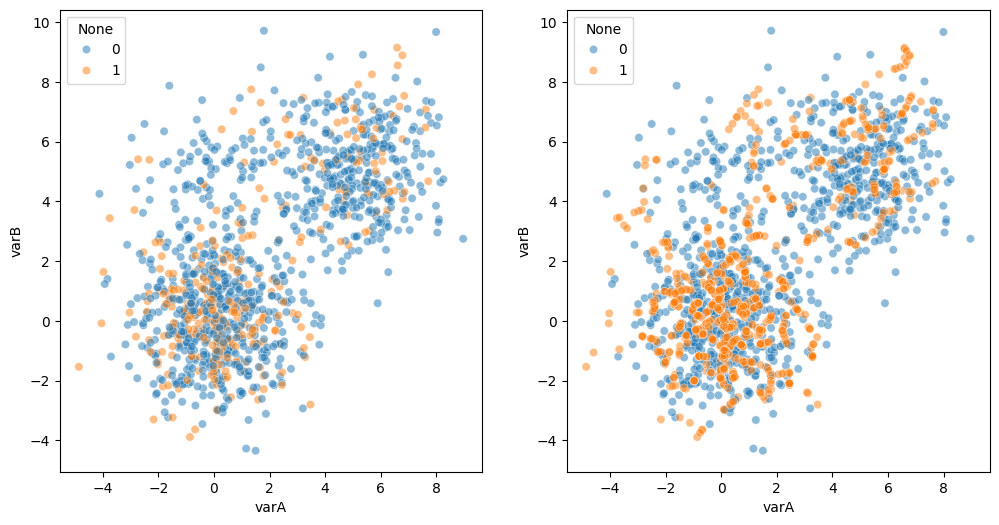

In [80]:
Scatterplot(X, y, X_res, y_res, alpha=0.5)